## Plot Total Mineral Column

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as pl
import matplotlib.pyplot as plt
from pathlib import Path
import zipfile
import dill

In [2]:
# data = {}

# for d in Path("../ModelOutputs/MineralSoil/").glob("VWC_*.dill"):
#     with open(d, "rb") as f:
#         out = dill.load(f)

#     data[d.stem] = out   

In [5]:

data = {}

for z in Path("../ModelOutputs/MineralSoil/").glob("VWC_*.zip"):
    with zipfile.ZipFile(z, 'r') as zip_ref:
        
        # assume one file inside each zip
        fname = zip_ref.namelist()[0]
        
        with zip_ref.open(fname) as f:
            out = dill.load(f)

    data[z.stem] = out

In [6]:
first_key = list(data.keys())[0]
out = data[first_key]

print(type(out))
print(dir(out))

<class 'soilice.utils.modelInOut'>
['T', 'T0', 'TBot', 'TInf', 'TTop', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', 'balanceClosure', 'const', 'dt', 'dz', 'jB', 'jT', 'jTopBC', 'm', 'nt', 'nz', 'opts', 'pars', 'plotBalance', 'psi0', 'psiT', 'psie', 'psif', 'qB', 'qT', 'rtol', 't', 'thetaI', 'thetaL', 'thetaT', 'u', 'z', 'z0', 'zMax']


In [7]:
import pandas as pd
import re

T_dfs = {}

for run_name, out in data.items():
    try:
        # extract theta1 from filename
        m = re.search(r"th1_(\d+\.\d+)", run_name)
        th1 = float(m.group(1))*100   # keep as float (0.10, 0.50, etc.)

        # build dataframe
        df = pd.DataFrame(
            out.T,
            columns=out.z,   
            index=out.t
        )
        # store
        T_dfs[f"df_{th1:.0f}"] = df

    except Exception as e:
        print(f"Skipped {run_name}: {e}")

In [8]:
J_dfs = {}

for run_name, out in data.items():
    try:
        # extract theta1 from filename
        m = re.search(r"th1_(\d+\.\d+)", run_name)
        th1 = float(m.group(1))*100   # keep as float (0.10, 0.50, etc.)

        # build dataframe
        df = pd.DataFrame(
            out.jT,   # real depths (much better than Depth_0 etc.)
            index=out.t
        )
        # store
        J_dfs[f"df_{th1:.0f}"] = df

    except Exception as e:
        print(f"Skipped {run_name}: {e}")

In [9]:
def fake_date(df):
    dfe = df.iloc[74:].reset_index(drop = True)
    n = len(dfe)
    dates = pd.date_range("2000-01-01", periods=n, freq="D")
    dfe.index = dates
    return dfe

In [10]:
# apply fake date to all dataframes and changes them in dictionary (temperature)
T_dfse = {}
T_dfse = {key: fake_date(df) for key, df in T_dfs.items()}

In [11]:
# apply fake date to all dataframes and changes them in dictionary (heat flux)
J_dfse = {}
J_dfse = {key: fake_date(df) for key, df in J_dfs.items()}

In [12]:
nz=1500
dz=np.zeros(nz)+0.01
dz[0:1000] = 0.01 # 0 -5
dz[1000:1500] = 0.02 # 5m - 10m
bz=np.hstack([0, np.cumsum(dz)])
z=(bz[:-1]+bz[1:])/2
zMax=bz[-1]


In [13]:
def depths(df,z):
    z1 = np.round(z, 3)
    df.columns = z1
    return df

In [14]:
# apply depths to all the dataframes
T_dfs = {key: depths(df,z) for key, df in T_dfs.items()}
T_dfse = {key: depths(df,z) for key, df in T_dfse.items()}

In [15]:
def depths(df):
    z1 = np.round(z, 3)
    df.columns = z1
    return df

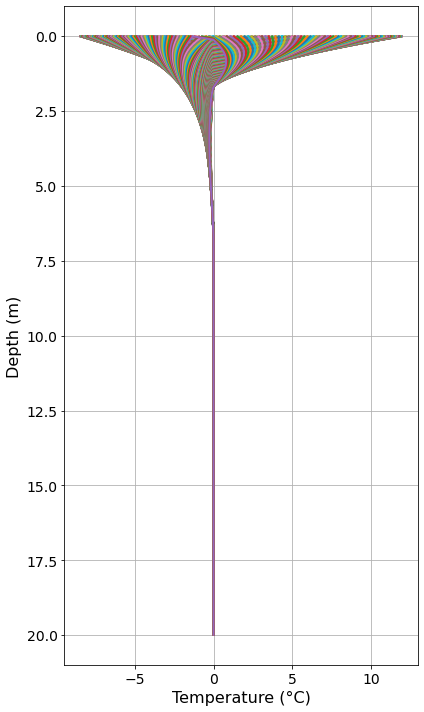

In [16]:
fig, ax = plt.subplots(figsize=(6, 10))

# Convert depth columns to floats
depths = T_dfs['df_40'].columns.astype(float)
example_times = T_dfs['df_40'].index[-365:]  # first 5 profile

for t in example_times:
    temps = T_dfs['df_40'].loc[t].values
    ax.plot(temps, depths, label=str(t), linewidth=2)

ax.invert_yaxis()  # depth increases downward
ax.set_xlabel("Temperature (°C)", fontsize=16)
ax.set_ylabel("Depth (m)", fontsize=16)
ax.tick_params(axis="both", labelsize=14)
ax.grid()

#ax.legend(title="Time")

plt.tight_layout()
plt.show()

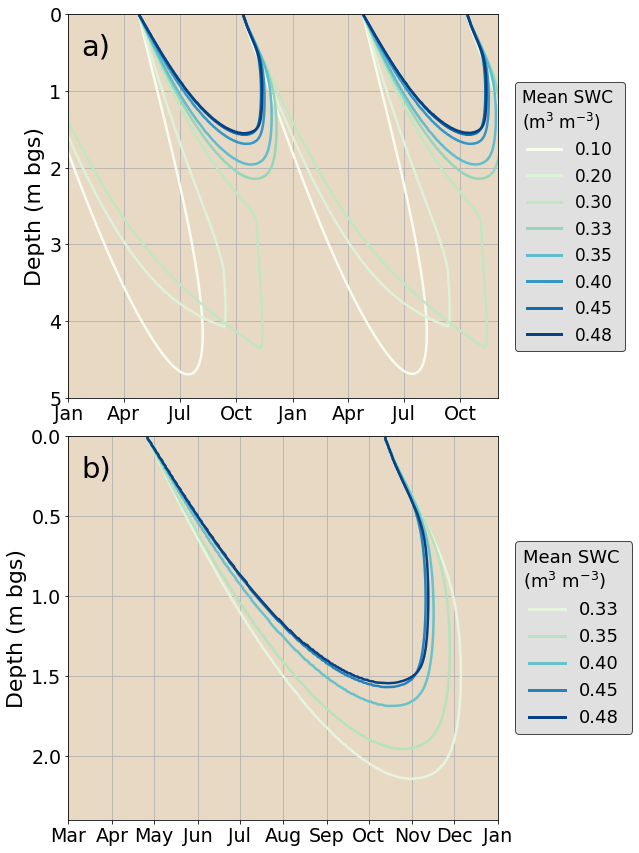

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.lines as mlines

# --- Your datasets and labels ---
datasets = (T_dfse['df_10'],T_dfse['df_20'],T_dfse['df_30'],T_dfse['df_33'],T_dfse['df_35'],T_dfse['df_40'],T_dfse['df_45'],T_dfse['df_48'])
labels = ('0.10','0.20','0.30','0.33','0.35','0.40','0.45','0.48')


# --- Generate progressively darker blue colors (light to dark) ---
blues = plt.cm.PuBu(np.linspace(0.1, 1.0, len(datasets)))  # 0.3 = light, 1.0 = dark

# --- Plot ---`
fig, ax = plt.subplots(2, 1,figsize=(9, 12))

ax[0].axhspan(0.0, 5, color='tan', alpha=0.5)

    
# --- Generate progressively darker blue colors (light to dark) ---
blues = plt.cm.GnBu(np.linspace(0, 1, len(datasets)))  # 0.3 = light, 1.0 = dark
for data, color in zip(datasets, blues):
    Time, Depth = np.meshgrid(data.index, data.columns, indexing='ij')
    ax[0].contour(Time, Depth, data.values, levels=[0], colors=[color], linewidths=2.5)
# --- Make custom legend lines (so colors show up) ---
legend_lines = [
    mlines.Line2D([], [], color=color, lw=3, label=label)
    for color, label in zip(blues, labels)
]
ax[0].invert_yaxis()
ax[0].set_ylabel("Depth (m bgs)", fontsize = 22)
#ax.set_xlim(3450, 3750)
ax[0].set_ylim(5, 0)
ax[0].tick_params(axis='both', labelsize=19) 
ax[0].grid()

# --- Add legend ---
leg = ax[0].legend(
    handles=legend_lines,
    loc='lower left',
    bbox_to_anchor=(1.02, 0.1),
    fontsize=17,
    title='Mean SWC \n(m$^3$ m$^{-3}$)',
    title_fontproperties={'size': 17}
)
leg.get_frame().set_facecolor('lightgrey')
leg.get_frame().set_alpha(0.7) 
leg.get_frame().set_edgecolor('black')

start_date = pd.to_datetime('2001-01-01')
end_date = pd.to_datetime('2002-12')
ax[0].set_xlim(start_date, end_date)
ax[0].xaxis.set_major_formatter(pl.matplotlib.dates.DateFormatter('%b'))
ax[0].text(
    0.03, 0.95,
    "a)",
    transform=ax[0].transAxes,
    fontsize=29,
    va='top')
##––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––##

datasets2 = (T_dfse['df_33'],T_dfse['df_35'],T_dfse['df_40'],T_dfse['df_45'],T_dfse['df_48'])
labels2 = ('0.33','0.35','0.40','0.45','0.48')

ax[1].axhspan(0.0, 5, color='tan', alpha=0.5)
blues2 = plt.cm.GnBu(np.linspace(0.1, 1, len(datasets2)))  # 0.3 = light, 1.0 = dark

for data, color in zip(datasets2, blues2):
    Time, Depth = np.meshgrid(data.index, data.columns, indexing='ij')
    ax[1].contour(Time, Depth, data.values, levels=[0], colors=[color], linewidths=2.5)
# --- Make custom legend lines (so colors show up) ---
legend_lines = [
    mlines.Line2D([], [], color=color, lw=3, label=label)
    for color, label in zip(blues2, labels2)
]
ax[1].invert_yaxis()
ax[1].set_ylabel("Depth (m bgs)", fontsize = 22)
ax[1].set_ylim(2.4, 0)
ax[1].tick_params(axis='both', labelsize=19) 
ax[1].grid()

# --- Add legend ---

leg2 = ax[1].legend(
    handles=legend_lines,
    loc='lower left',
    bbox_to_anchor=(1.02, 0.2),
    fontsize=18,
    title='Mean SWC \n(m$^3$ m$^{-3}$)',
    title_fontproperties={'size': 18}
)

leg2.get_frame().set_facecolor('lightgrey')
leg2.get_frame().set_alpha(0.7) 
leg2.get_frame().set_edgecolor('black')
start_date2 = pd.to_datetime('2002-03-01')
end_date2 = pd.to_datetime('2003-01')
ax[1].set_xlim(start_date2, end_date2)
ax[1].xaxis.set_major_formatter(pl.matplotlib.dates.DateFormatter('%b'))
ax[1].text(
    0.03, 0.95,
    "b)",
    transform=ax[1].transAxes,
    fontsize=29,
    va='top')   
    
fig.tight_layout()
fig.subplots_adjust(hspace=0.1)

In [19]:
dfs = [T_dfs['df_10'],T_dfs['df_20'],T_dfs['df_25'],T_dfs['df_30'],T_dfs['df_33'],T_dfs['df_35'],T_dfs['df_40'],T_dfs['df_45'],T_dfs['df_48']]

In [20]:
def equilibriated(df,start =900 , end=1450, tol=0.01):
    depths = df.columns.astype(float)
    L = end - start  # length of the window

    # ---- Last year ----
    sub1 = df.iloc[start:end]
    mask1 = sub1.where(sub1 >= 0)
    d1 = mask1.apply(lambda r: depths[r.notna()].max() if r.notna().any() else np.nan, axis=1).max()

    # ---- Previous year ----
    sub2 = df.iloc[start-L:start]
    mask2 = sub2.where(sub2 >= 0)
    d2 = mask2.apply(lambda r: depths[r.notna()].max() if r.notna().any() else np.nan, axis=1).max()

    # ---- Handle missing thaw ----
    if np.isnan(d1) or np.isnan(d2):
        print("No thaw detected in one or both windows.")
        return d1, d2

    # ---- Compare ----
    diff = abs(d1 - d2)
    if diff <= tol:
        print(f"Equilibrated: {d1:.3f} vs {d2:.3f} (diff = {diff:.4f})")
    else:
        print(f"Different: {d1:.3f} vs {d2:.3f} (diff = {diff:.4f})")
    return d1, d2

In [21]:
for df in dfs:
    equilibriated(df)

Equilibrated: 19.990 vs 19.990 (diff = 0.0000)
Equilibrated: 19.990 vs 19.990 (diff = 0.0000)
Equilibrated: 19.990 vs 19.990 (diff = 0.0000)
Equilibrated: 19.990 vs 19.990 (diff = 0.0000)
Equilibrated: 2.135 vs 2.135 (diff = 0.0000)
Equilibrated: 1.955 vs 1.955 (diff = 0.0000)
Equilibrated: 1.685 vs 1.685 (diff = 0.0000)
Equilibrated: 1.565 vs 1.565 (diff = 0.0000)
Equilibrated: 1.545 vs 1.545 (diff = 0.0000)


In [22]:
dfs = [T_dfs['df_20'],T_dfs['df_25'],T_dfs['df_30'],T_dfs['df_35'], T_dfs['df_40'], T_dfs['df_45'], T_dfs['df_48']]

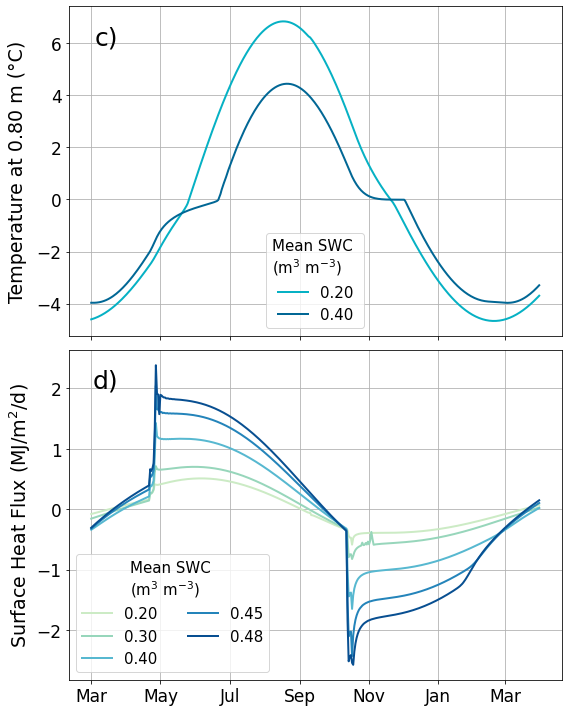

In [23]:
import numpy as np
import matplotlib.pyplot as pl

fig, ax = pl.subplots(2, 1, figsize=(8, 10), sharex=True)

a = '2001-03'
b = '2002-03'

# ---------- TOP PANEL (unchanged) ----------
ax[0].plot(
    T_dfse['df_20'][0.805].loc[a:b],
    label='0.20',
    color='xkcd:turquoise blue',
    linewidth=2
)

ax[0].plot(
    T_dfse['df_40'][0.805].loc[a:b],
    label='0.40',
    color='xkcd:peacock blue',
    linewidth=2
)

ax[0].xaxis.set_major_formatter(pl.matplotlib.dates.DateFormatter('%b'))
ax[0].grid()

# ---------- BOTTOM PANEL (GnBu gradient) ----------

# J datasets and labels (ordered low → high VWC)
J_datasets = (
    J_dfse['df_20'].loc[a:b] / 1e6,
    J_dfse['df_30'].loc[a:b] / 1e6,
    J_dfse['df_40'].loc[a:b] / 1e6,
    J_dfse['df_45'].loc[a:b] / 1e6,
    J_dfse['df_48'].loc[a:b] / 1e6,
)

J_labels = ('0.20','0.30','0.40','0.45','0.48')

# Light → dark GnBu
gnbu = pl.cm.GnBu(np.linspace(0.25, 0.95, len(J_datasets)))

for data, label, color in zip(J_datasets, J_labels, gnbu):
    ax[1].plot(data, label=label, color=color, linewidth=2)

ax[1].grid()
ax[1].xaxis.set_major_formatter(pl.matplotlib.dates.DateFormatter('%b'))

# ---------- LEGENDS & LABELS ----------
ax[0].legend(
    fontsize=15,
    loc='lower center',
    title='Mean SWC \n(m$^3$ m$^{-3}$)',
    title_fontsize=15
)

ax[1].legend(
    fontsize=15,
    loc='lower left',
    title='Mean SWC \n(m$^3$ m$^{-3}$)',
    title_fontsize=15, ncol = 2
)

ax[1].set_ylabel('Surface Heat Flux (MJ/m$^2$/d)', fontsize=19)
ax[0].set_ylabel('Temperature at 0.80 m (°C)', fontsize=19, labelpad=10)

ax[0].tick_params(axis='both', labelsize=17)
ax[1].tick_params(axis='both', labelsize=17)

fig.subplots_adjust(hspace=0.1)

# ---------- PANEL LABELS ----------
ax[0].text(
    0.1, 0.87, "c)",
    transform=ax[0].transAxes,
    fontsize=25,
    ha="right",
    va="bottom"
)

ax[1].text(
    0.1, 0.87, "d)",
    transform=ax[1].transAxes,
    fontsize=25,
    ha="right",
    va="bottom"
)

pl.tight_layout()

Text(0.33, 1.249, 'e)')

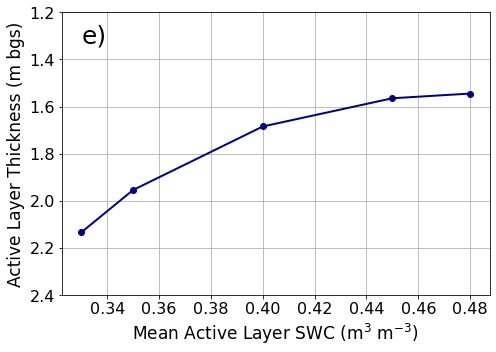

In [24]:
import matplotlib.pyplot as plt
# Data
ALT = [2.135,1.955, 1.685, 1.565, 1.545]
VWC = [0.33,0.35,0.40,0.45,0.48]

# Plot
plt.figure(figsize=(7,5))
plt.plot(VWC, ALT, marker='o', linewidth=2, color = 'darkblue')

plt.xlabel('Mean Active Layer SWC (m$^3$ m$^{-3}$)', fontsize=17)
plt.ylabel('Active Layer Thickness (m bgs)', fontsize=17)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.gca().invert_yaxis()
plt.grid(True)
plt.ylim(2.4,1.2)
plt.tight_layout()
plt.text(
    0.33,1.249,                 # x, y in data coordinates
    'e)',
    fontsize=25,
    ha='left',
    va='top'
)